In [3]:
#Importing the required libraries
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.sparse import hstack, csr_matrix

In [4]:
#Loading the training and testing data
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
nlp = spacy.load("en_core_web_sm")

In [5]:
#Function to extract linguistic features like parts of speech (POS) and named entities (NER)
def extract_structural_features(text):
    doc = nlp(text)
    return {
        "num_nouns": sum(1 for token in doc if token.pos_ == "NOUN"), #Count of Nouns
        "num_verbs": sum(1 for token in doc if token.pos_ == "VERB"), #Count of Verbs
        "num_adjs": sum(1 for token in doc if token.pos_ == "ADJ"), #Count of Adjectives
        "num_entities": len(doc.ents), #Total named entities
        "has_cardinal": int(any(ent.label_ == "CARDINAL" for ent in doc.ents)), #Binary flag for cardinal numbers
        "starts_with_verb": int(doc[0].pos_ == "VERB") if doc else 0 #To check if the sentence starts with a Verb or not
    }


In [6]:
#Function to extract linguistic features like parts of speech and named entities
train_struct_features = pd.DataFrame([extract_structural_features(t) for t in df["text"]])

#Transforming text data into TF-IDF vectors using unigrams and bigrams
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_tfidf = tfidf.fit_transform(df["text"])

#Normalizing the structural features to ensure they're on the same scale as TF-IDF features
scaler = StandardScaler()
X_train_struct = scaler.fit_transform(train_struct_features)

#Concatenating the TF-IDF matrix and the structural feature matrix to form the final training input
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_struct)])

In [7]:
#Encoding the output labels (categories) into integers for training
le = LabelEncoder()
y_train = le.fit_transform(df["category"])

#Extracting and transforming test data features using the same vectorizer and scaler from training
test_struct_features = pd.DataFrame([extract_structural_features(t) for t in test_df["text"]])

#Reusing the trained TF-IDF vectorizer
X_test_tfidf = tfidf.transform(test_df["text"])
X_test_struct = scaler.transform(test_struct_features)

In [8]:
#Combining the test features
X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_struct)])
y_test = le.transform(test_df["category"])

#Training logistic regression classifier on the combined feature set
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_final, y_train)

#Generating predictions on the test set
y_pred = clf.predict(X_test_final)

In [9]:
#Printing overall performance metrics: precision, recall, F1-score per class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.88      0.90      0.89        40
                                activate_my_card       1.00      0.95      0.97        40
                                       age_limit       1.00      0.97      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.92      0.85      0.88        40
                                automatic_top_up       1.00      0.88      0.93        40
         balance_not_updated_after_bank_transfer       0.67      0.75      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.78      0.95      0.85        40
                         beneficiary_not_allowed       0.88      0.88      0.88        40
                                 cancel_transfer       0.88      0.88     

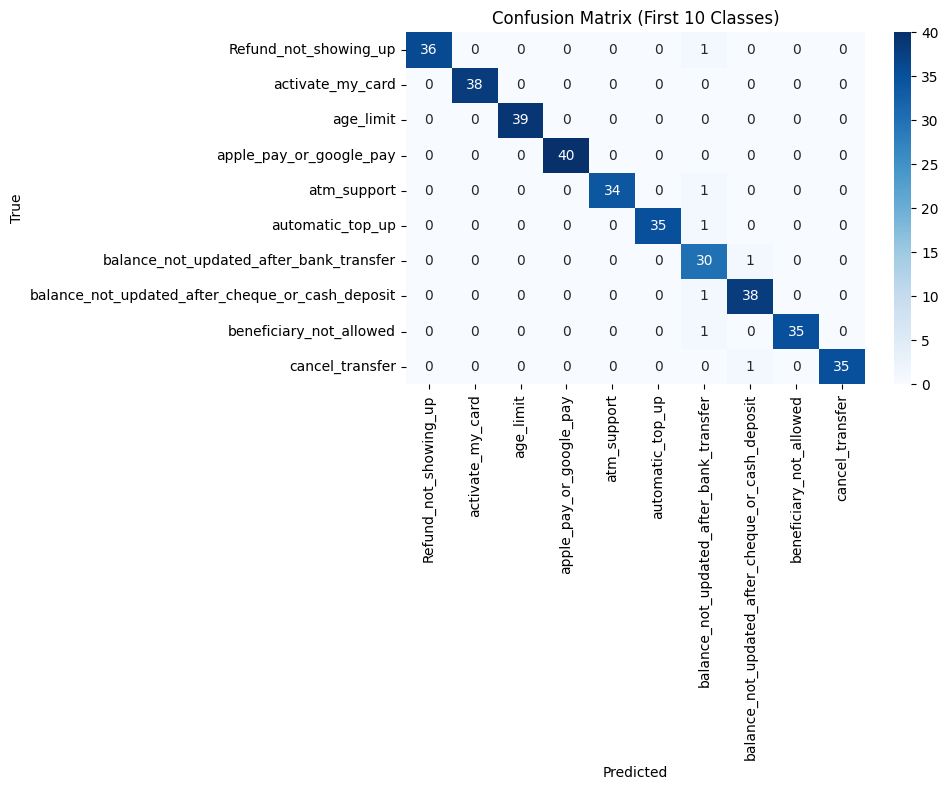

In [10]:
#Confusion matrix for the first 10 intent classes
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm[:10, :10], cmap='Blues', annot=True, fmt='d',
            xticklabels=le.classes_[:10], yticklabels=le.classes_[:10])
plt.title('Confusion Matrix (First 10 Classes)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

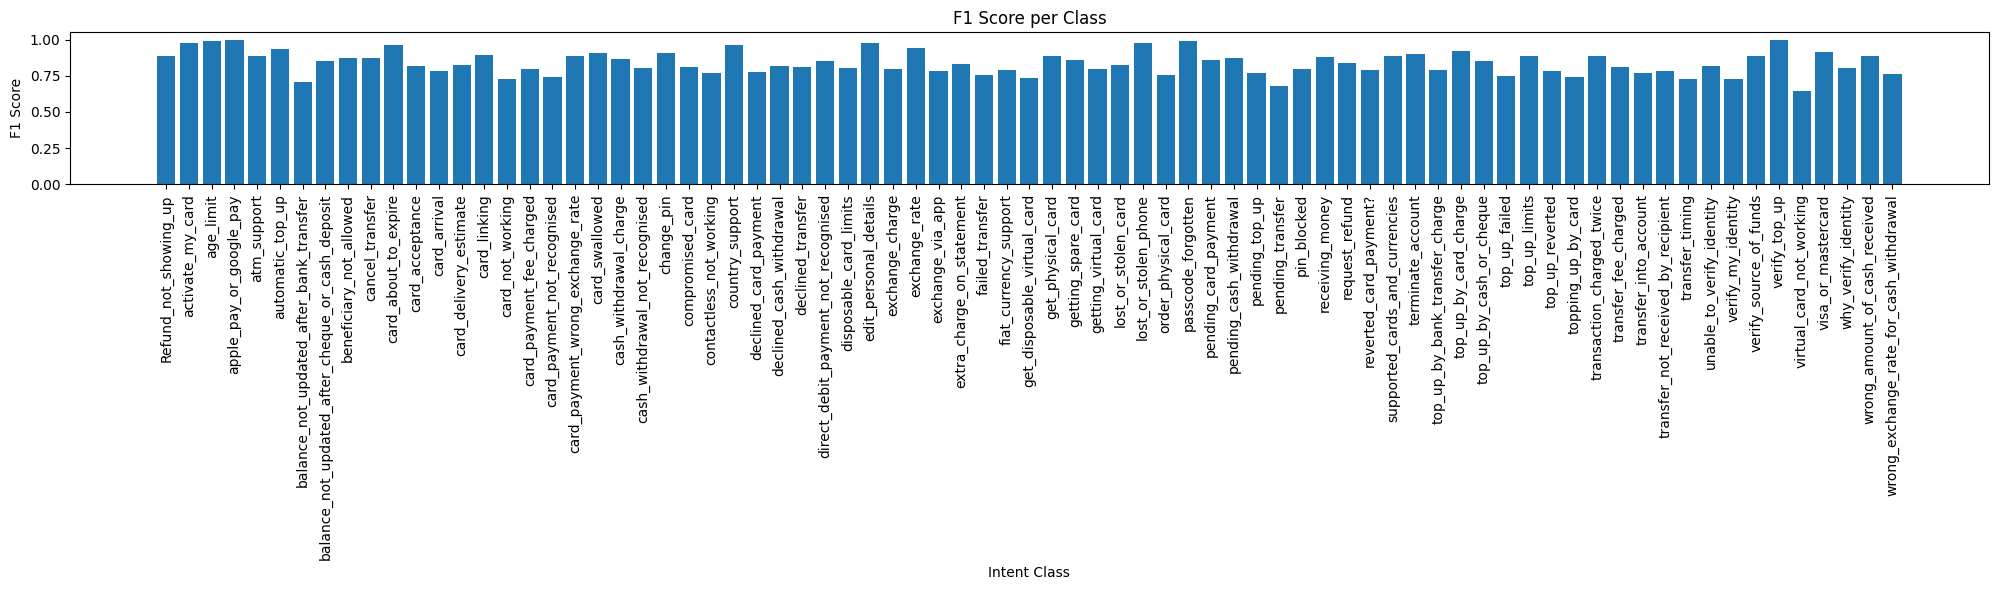

In [11]:
#Calculating F1 scores for each intent class and plotting them
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
plt.figure(figsize=(20, 6))
plt.bar(le.classes_, f1)
plt.xticks(rotation=90)
plt.title('F1 Score per Class')
plt.xlabel('Intent Class')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()

In [12]:
#Identifying and displaying examples of misclassified queries for qualitative analysis
wrong_idx = np.where(y_test != y_pred)[0]
misclassified_df = test_df.iloc[wrong_idx].copy()
misclassified_df["true"] = le.inverse_transform(y_test[wrong_idx])
misclassified_df["predicted"] = le.inverse_transform(y_pred[wrong_idx])
print("\nTop Misclassified Examples:\n")
print(misclassified_df[["text", "true", "predicted"]].head())


Top Misclassified Examples:

                                                 text          true  \
0                            How do I locate my card?  card_arrival   
2   I ordered a card but it has not arrived. Help ...  card_arrival   
5                            When will I get my card?  card_arrival   
11                How long does a card delivery take?  card_arrival   
15  I have been waiting longer than expected for m...  card_arrival   

                             predicted  
0                    get_physical_card  
2   transfer_not_received_by_recipient  
5               card_delivery_estimate  
11              card_delivery_estimate  
15  transfer_not_received_by_recipient  
